In [39]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import scanpy as sc
import muon as mu
import builtins #this is because np is shadowing built in sum but can be overwritten using builtins
from scipy.stats import gaussian_kde
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

mpl.rcParams.update({
    # --- Fonts: keep text editable ---
    'pdf.fonttype': 'truetype',   # same as 42, ensures TrueType fonts
    'ps.fonttype': 'truetype',    # for EPS compatibility
    'svg.fonttype': 'none',       # keeps SVG text as text, not outlines

    # --- General style niceties ---
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.family': 'sans-serif'
})

from IPython.display import display, HTML
display(HTML("<style>.jp-Cell { margin-left: -20% !important; margin-right: -15% !important; }</style>"))

In [3]:
#V2_GEO uses new h5mu master file  as the data source

In [5]:
#Functions

In [7]:
#Rasterization function
def rasterize_all(fig):
    for ax in fig.axes:
        for artist in ax.collections:
            artist.set_rasterized(True)

#usage - add rasterize_all(fig) before saving figure

In [9]:
#Variable, settings, colors

In [11]:
#Variables
lclusters = ['2','6','17','21','5','16','12', '1','11','24','4','0','19','3', '10', '7','15','23','18',  '14', '8', '20', '22', '13','9'] #ordered cluster list
lclusters_int = [int(i) for i in lclusters]

In [13]:
#colors
colors_sheet = pd.read_excel('../data/production_color_v1.xlsx') #test sheet

#make leiden cluster color dictionary
colors_dict = dict(zip(colors_sheet.leiden, colors_sheet.colour))

#make DevCell color dictionary
dc_colors_dict = {}
for k, v in dict(zip(colors_sheet.DevCell, colors_sheet.DC_color)).items():
    if isinstance(k, str):
        dc_colors_dict[k] = v

#make Patient color dictionary
pat_colors_dict = {}
for k, v in dict(zip(colors_sheet.Patient, colors_sheet.Patient_color)).items():
    if isinstance(k, str):
        pat_colors_dict[k] = v

#make Patient color dictionary - extra version as one will be updated later
pat_colors_dict2 = {}
for k, v in dict(zip(colors_sheet.Patient, colors_sheet.Patient_color)).items():
    if isinstance(k, str):
        pat_colors_dict2[k] = v

#make sequencing batch color dictionary
batch_colors_dict = {}
for k, v in dict(zip(colors_sheet.Pool, colors_sheet.Pool_color)).items():
    if isinstance(k, str):
        batch_colors_dict[k] = v

In [15]:
#1. DevCell annotations

In [17]:
#2. Patient source annotations

In [19]:
#Read in data from master h5mu file
adata = mu.read_h5ad('../Data/GEO_data_file_v1.h5mu', mod = 'rna')
print(adata.shape)
adata_all = adata.obs.copy() 

(38231, 28762)


In [21]:
#Add devcell annotations to the adata.obs (integrated into this version so just harmonising column names)
adata.obs['devcell'] = adata.obs['singleR_annotation'] #column called 'singleR_annotation' in updated master h5mu

In [23]:
#5. UMAPs with different colour overlays

In [25]:
#Color palettes and variables for UMAPS
healthy_leiden = ['5','16','1','21','17','11','12','24','6','2']
healthy_leiden_int = [int(i) for i in healthy_leiden]
atypical_leiden = ['19','4','14','3','23','8','20','22','25','0','13','9','15', '7','18','10']
atypical_leiden_int = [int(i) for i in atypical_leiden]
all_leiden = lclusters
all_leiden_int = lclusters_int

In [27]:
#Create colour sub dictionaries for UMAPS _ healthy
cd_healthy_leiden = {}
cd_healthy_leiden_legend = {}
for k in colors_dict.keys():
    if k in healthy_leiden_int:
        cd_healthy_leiden[str(k)] = colors_dict[k]

#Create colour sub dictionaries for UMAPS _ atypical
cd_atypical_leiden = {}
cd_atypical_leiden_legend = {}
for k in colors_dict.keys():
    if k in atypical_leiden_int:
        cd_atypical_leiden[str(k)] = colors_dict[k]

#Create colour sub dictionaries for UMAPS _ all clusters
cd_all_leiden = {}
cd_all_leiden_legend = {}
for k in colors_dict.keys():
    if k in all_leiden_int:
        cd_all_leiden[str(k)] = colors_dict[k]

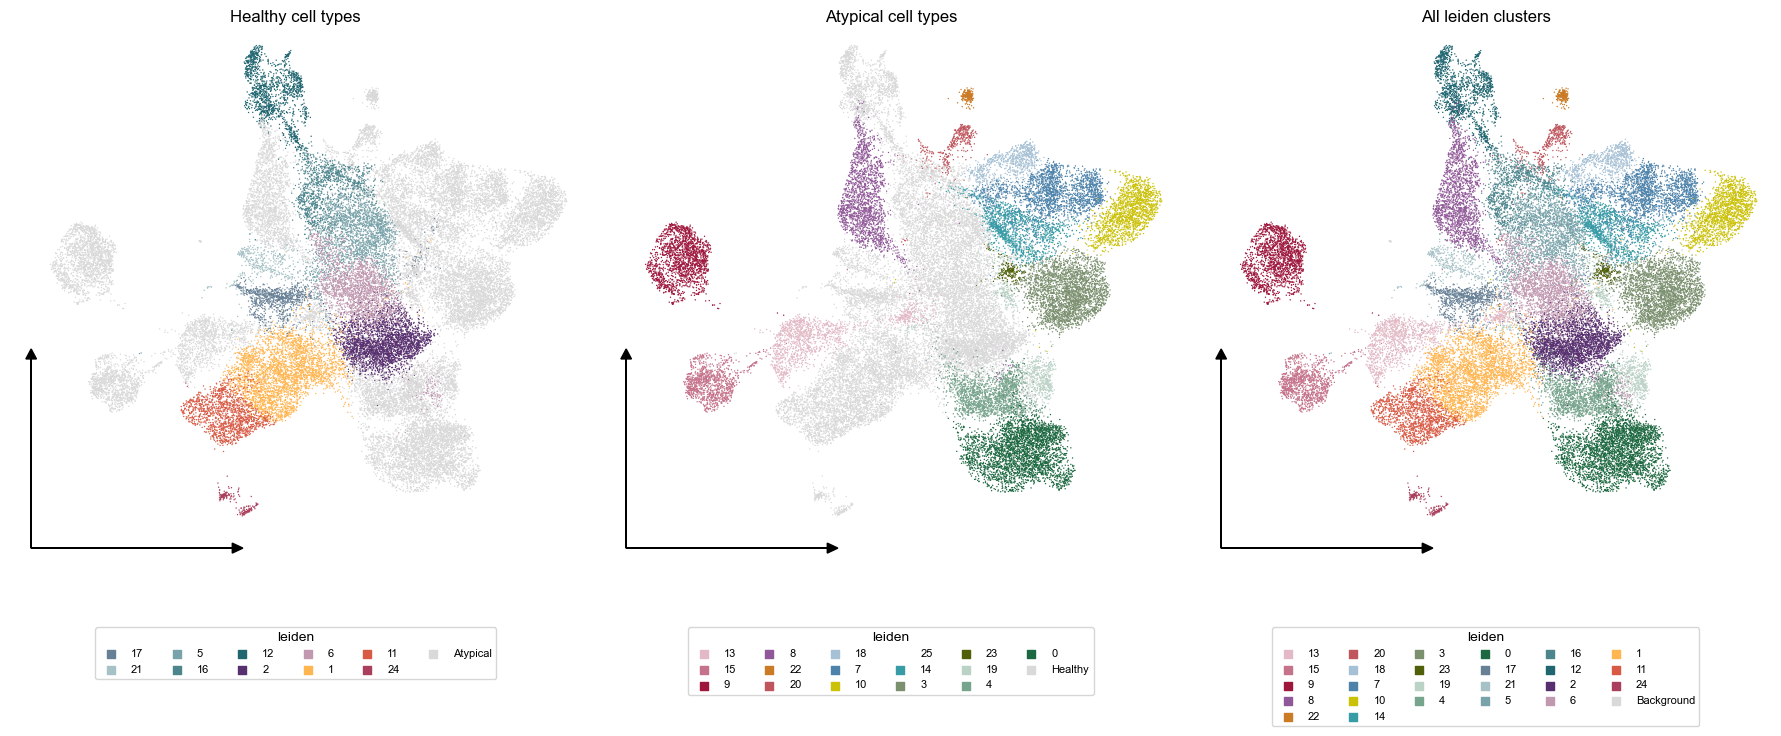

In [29]:
#UMAPS showing healthy and atypical clusters
fig, ax = plt.subplots(1,3, figsize = (18,7.5))

umap = adata.obsm['X_umap']
group_col = 'leiden'

#Healthy plot
#Use cd_healthy_leiden for colors
fallback_color = colors_dict['Atyp']
# Build color mapping with fallback
colors = adata.obs[group_col].map(lambda x: cd_healthy_leiden.get(x, fallback_color))

ax[0].scatter(umap[:,0], umap[:,1], c=colors, s=1, linewidth=0)

# Add legend
for group, color in cd_healthy_leiden.items():
    ax[0].scatter([], [], c=color, label=group, marker = 's')
if fallback_color is not None:
    ax[0].scatter([], [], c=fallback_color, label="Atypical", marker = 's')

ax[0].legend(title=group_col, bbox_to_anchor=(0.5,-0.1), loc="upper center", ncols = 6, fontsize = 8)
ax[0].set_title('Healthy cell types')


#Atypical plot
#Use cd_atypical_leiden for colors
fallback_color2 = colors_dict['HSPC-L']
# Build color mapping with fallback
colors2 = adata.obs[group_col].map(lambda x: cd_atypical_leiden.get(x, fallback_color2))

ax[1].scatter(umap[:,0], umap[:,1],c=colors2, s=1, linewidth=0)

# Add legend
for group, color in cd_atypical_leiden.items():
    ax[1].scatter([], [], c=color, label=group, marker = 's')
if fallback_color2 is not None:
    ax[1].scatter([], [], c=fallback_color2, label="Healthy", marker = 's')

ax[1].legend(title=group_col, bbox_to_anchor=(0.5,-0.1), loc="upper center", ncols = 6, fontsize = 8)
ax[1].set_title('Atypical cell types')

#All leiden clusters plot
#use cd_all_leiden for colors
fallback_color3 = colors_dict['Background']
# Build color mapping with fallback
colors3 = adata.obs[group_col].map(lambda x: cd_all_leiden.get(x, fallback_color3))

ax[2].scatter(umap[:,0], umap[:,1],c=colors3, s=1, linewidth=0)

# Add legend
for group, color in cd_all_leiden.items():
    ax[2].scatter([], [], c=color, label=group, marker = 's')
if fallback_color3 is not None:
    ax[2].scatter([], [], c=fallback_color3, label="Background", marker = 's')

ax[2].legend(title=group_col, bbox_to_anchor=(0.5,-0.1), loc="upper center", ncols = 6, fontsize = 8)
ax[2].set_title('All leiden clusters')


for i in range(len(plt.gcf().axes)):
    ax[i].set_xlim(-6, 21)
    ax[i].set_ylim(-9, 18)
    ax[i].arrow(-5,-8,0,10,color='k',lw=1,length_includes_head=True, head_width=0.5,head_length=0.5)
    ax[i].arrow(-5,-8,10,0,color='k',lw=1,length_includes_head=True, head_width=0.5,head_length=0.5)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    for d in ['top', 'left', 'right', 'bottom']:
        ax[i].spines[d].set_visible(False) 


fig.tight_layout()
rasterize_all(fig)
#fig.savefig('../Figures/1_Healthy_atypical_umaps_leiden_v2_GEO.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

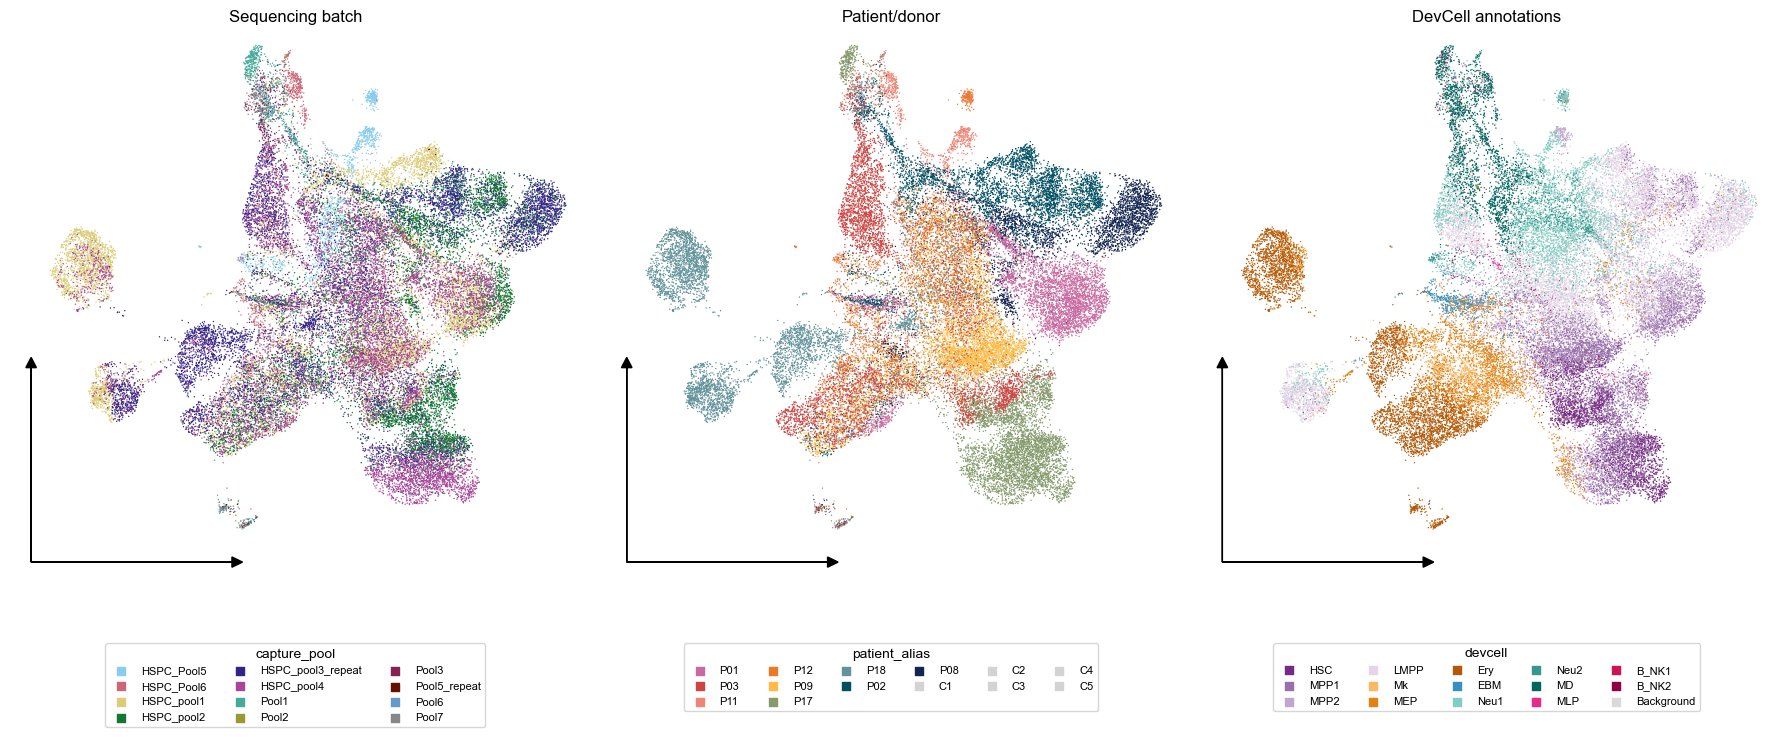

In [31]:
#UMAPS showing pool, patient, devcell
fig, ax = plt.subplots(1,3, figsize = (18,7.5))

umap = adata.obsm['X_umap']

#-----Sequence pool
group_col_0 = 'capture_pool'
#Use batch_colors_dict for colors
fallback_color = '#ffffff'
# Build color mapping with fallback (shouldn't be needed though)
colors = adata.obs[group_col_0].map(lambda x: batch_colors_dict.get(x, fallback_color))

ax[0].scatter(umap[:,0], umap[:,1],c=colors, s=1, linewidth=0)

#Add legend
for group, color in batch_colors_dict.items():
    ax[0].scatter([], [], c=color, label=group, marker='s')

ax[0].legend(title=group_col_0, bbox_to_anchor=(0.5,-0.1), loc="upper center", ncols = 3, fontsize = 8)
ax[0].set_title('Sequencing batch')


#-----Patient alias plot
group_col_1 = 'patient_alias'
#Use pat_colors_dict for colours
# Build color mapping with fallback(shouldn't be needed though)
colors2 = adata.obs[group_col_1].map(lambda x: pat_colors_dict.get(x, fallback_color))

ax[1].scatter(umap[:,0], umap[:,1], c=colors2, s=1, linewidth=0)

# Add legend
for group, color in pat_colors_dict.items():
    ax[1].scatter([], [], c=color, label=group, marker='s')


ax[1].legend(title=group_col_1, bbox_to_anchor=(0.5,-0.1), loc="upper center", ncols = 6, fontsize = 8)
ax[1].set_title('Patient/donor')


#-----DevCell annotations ####Need to add DevCell annotations into the metadata
#use dc_colors_dict for colors
group_col_3 = 'devcell'
fallback_color3 = colors_dict['Background']
# Build color mapping with fallback
colors3 = adata.obs[group_col_3].map(lambda x: dc_colors_dict.get(x, fallback_color3))

ax[2].scatter(umap[:,0], umap[:,1],c=colors3, s=1, linewidth=0)

# Add legend
#for group, color in cd_all_leiden_legend.items():
for group, color in dc_colors_dict.items():
    ax[2].scatter([], [], c=color, label=group, marker = 's')
if fallback_color3 is not None:
    ax[2].scatter([], [], c=fallback_color3, label="Background", marker = 's')

ax[2].legend(title=group_col_3, bbox_to_anchor=(0.5,-0.1), loc="upper center", ncols = 5, fontsize = 8)
ax[2].set_title('DevCell annotations')

for i in range(len(plt.gcf().axes)):
    ax[i].set_xlim(-6, 21)
    ax[i].set_ylim(-9, 18)
    ax[i].arrow(-5,-8,0,10,color='k',lw=1,length_includes_head=True, head_width=0.5,head_length=0.5)
    ax[i].arrow(-5,-8,10,0,color='k',lw=1,length_includes_head=True, head_width=0.5,head_length=0.5)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    for d in ['top', 'left', 'right', 'bottom']:
        ax[i].spines[d].set_visible(False) 


fig.tight_layout()
rasterize_all(fig)
#fig.savefig('../Figures/1_Pool_patient_devcell_umaps_leiden_v2_GEO.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

In [33]:
#Total cell number
adata.obs.shape[0]

38231

In [35]:
#Total cells from CITEseq pools
adata.obs.loc[adata.obs['capture_pool'].isin(['HSPC_pool1', 'HSPC_pool2', 'HSPC_pool3_repeat', 'HSPC_pool4'])].shape[0]

33950

In [37]:
#Addition of cluster outlines

In [41]:
def _kde_contour(ax, pts, coverage=0.95, gridsize=250, bw_adjust=1.0, **plot_kwargs):
    if pts.shape[0] < 10:
        return

    kde = gaussian_kde(pts.T)
    kde.set_bandwidth(bw_method=kde.factor * bw_adjust)

    xmin, ymin = pts.min(axis=0)
    xmax, ymax = pts.max(axis=0)
    pad_x = 0.1 * (xmax - xmin)
    pad_y = 0.1 * (ymax - ymin)

    x = np.linspace(xmin - pad_x, xmax + pad_x, gridsize)
    y = np.linspace(ymin - pad_y, ymax + pad_y, gridsize)
    X, Y = np.meshgrid(x, y)

    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    dx = x[1] - x[0]
    dy = y[1] - y[0]
    prob = Z * dx * dy

    idx = np.argsort(Z.ravel())[::-1]
    cumulative = np.cumsum(prob.ravel()[idx])
    cutoff_index = np.searchsorted(cumulative, coverage)
    level = Z.ravel()[idx][cutoff_index]

    ax.contour(X, Y, Z, levels=[level], **plot_kwargs)


def outline_leiden_group_components_kde_merge_min_dist(
    ax,
    umap_xy,
    leiden_series,
    clusters,
    k=25,                   # kNN for initial connectivity
    min_component=30,       # keep components >= this size
    merge_dist=0.8,         # merge if components come within this distance
    merge_knn=10,           # neighbors to probe for min-distance merging
    coverage=0.95,
    gridsize=250,
    bw_adjust=0.8,
    **plot_kwargs
):
    labels = np.asarray(leiden_series).astype(str)
    clusters = set(map(str, clusters))
    pts = umap_xy[np.isin(labels, list(clusters))]

    n = pts.shape[0]
    if n < 10:
        return

    # --- 1) initial connected components via kNN graph
    k_eff = min(k, n - 1)
    nbrs = NearestNeighbors(n_neighbors=k_eff + 1).fit(pts)
    _, indices = nbrs.kneighbors(pts)

    row = np.repeat(np.arange(n), k_eff)
    col = indices[:, 1:].ravel()
    data = np.ones(len(row), dtype=np.uint8)
    A = csr_matrix((data, (row, col)), shape=(n, n))
    A = A.maximum(A.T)
    n_comp, comp_labels = connected_components(A, directed=False)

    comps = []
    for cid in range(n_comp):
        ix = np.where(comp_labels == cid)[0]
        if ix.size >= min_component:
            comps.append(ix)

    if not comps:
        _kde_contour(ax, pts, coverage=coverage, gridsize=gridsize, bw_adjust=bw_adjust, **plot_kwargs)
        return

    # --- 2) merge components by minimum point-to-point distance (approx via kNN)
    # Build a NN index on ALL points once
    mk = min(merge_knn + 1, n)  # +1 because self may appear
    nn_all = NearestNeighbors(n_neighbors=mk).fit(pts)

    m = len(comps)

    # Union-Find to merge based on distances
    parent = np.arange(m)

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    # For each component i, look at nearest neighbors of its points;
    # if any neighbor belongs to component j and is within merge_dist, merge i and j.
    # To do this efficiently, map point index -> component index (for kept components only)
    point_to_comp = -np.ones(n, dtype=int)
    for ci, ix in enumerate(comps):
        point_to_comp[ix] = ci

    for ci, ix in enumerate(comps):
        # query neighbors for points in this component
        dists, neigh = nn_all.kneighbors(pts[ix])
        # flatten
        dists = dists.ravel()
        neigh = neigh.ravel()

        # ignore self matches at distance 0 by requiring >0
        mask = (dists > 0) & (dists <= merge_dist)
        neigh = neigh[mask]

        # which components do these neighbors belong to?
        cj = point_to_comp[neigh]
        cj = cj[cj >= 0]
        for other in np.unique(cj):
            union(ci, other)

    # Build merged groups
    groups = {}
    for ci in range(m):
        r = find(ci)
        groups.setdefault(r, []).append(ci)

    merged = []
    for _, comp_ids in groups.items():
        merged_ix = np.concatenate([comps[j] for j in comp_ids])
        merged.append(merged_ix)

    merged.sort(key=lambda ix: ix.size, reverse=True)

    # --- 3) outline each merged component
    for ix in merged:
        _kde_contour(ax, pts[ix], coverage=coverage, gridsize=gridsize, bw_adjust=bw_adjust, **plot_kwargs)

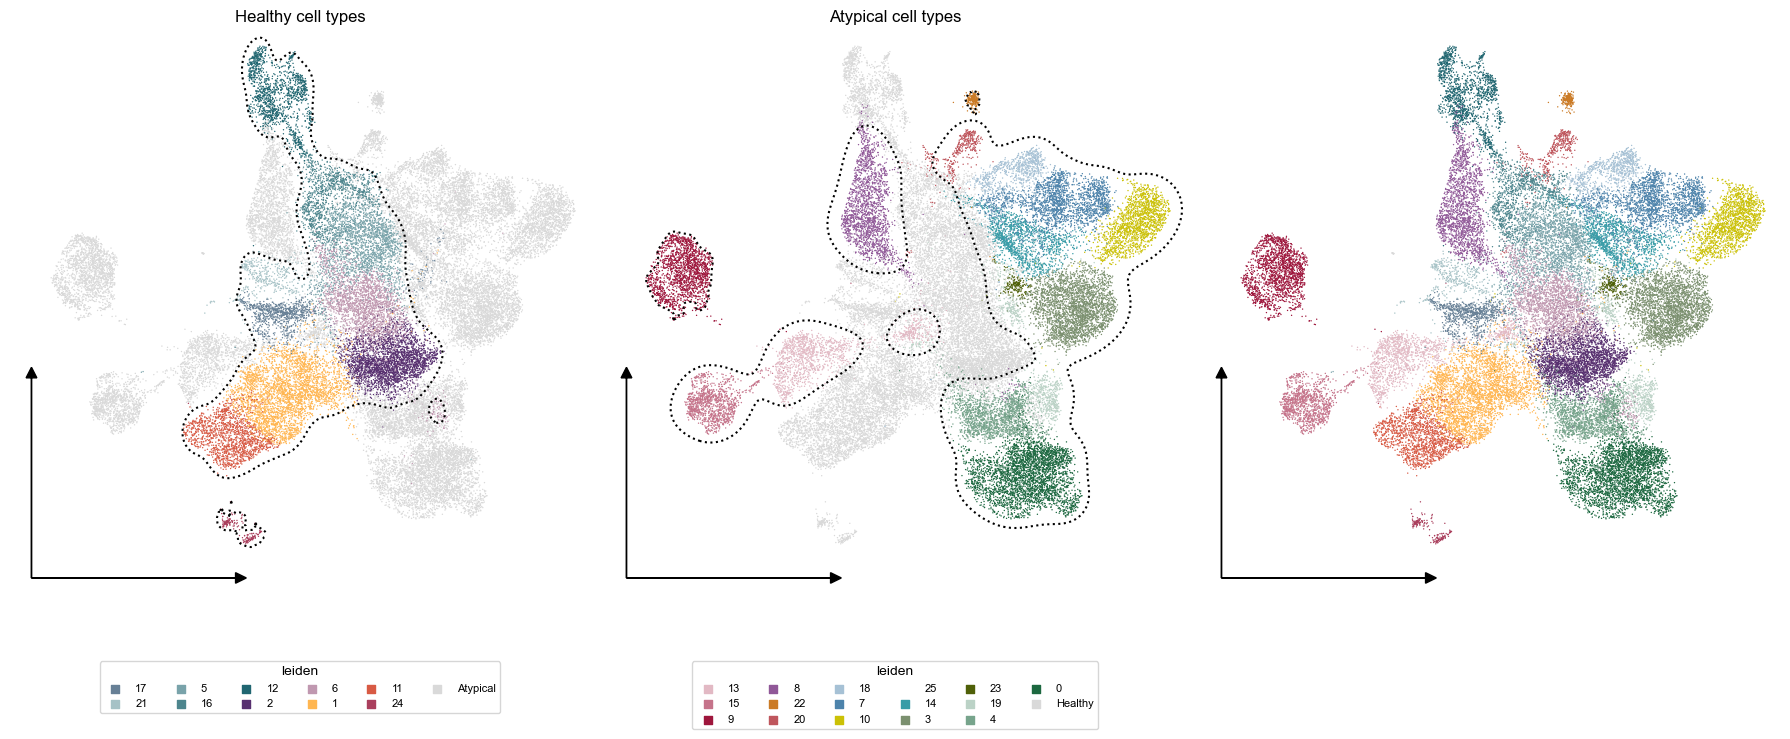

In [43]:
#UMAPS showing healthy and atypical clusters
fig, ax = plt.subplots(1,3, figsize = (18,7.5))

umap = adata.obsm['X_umap']
group_col = 'leiden'

#Healthy plot
#Use cd_healthy_leiden for colors
fallback_color = colors_dict['Atyp']
# Build color mapping with fallback
colors = adata.obs[group_col].map(lambda x: cd_healthy_leiden.get(x, fallback_color))

ax[0].scatter(umap[:,0], umap[:,1], c=colors, s=1, linewidth=0)

#Add outline

group_to_outline = ['5','16','1','21','17','11','12','24','6','2']

outline_leiden_group_components_kde_merge_min_dist(
    ax[0],
    umap_xy=umap,
    leiden_series=adata.obs[group_col],
    clusters=group_to_outline,
    k=25,
    min_component=30,
    merge_dist=0.7,     # try 0.7–1.5
    merge_knn=10,
    coverage=0.95,
    bw_adjust=0.6,
    colors='k',
    linewidths=1.5,
    linestyles=':'
)


# Add legend
for group, color in cd_healthy_leiden.items():
    ax[0].scatter([], [], c=color, label=group, marker = 's')
if fallback_color is not None:
    ax[0].scatter([], [], c=fallback_color, label="Atypical", marker = 's')

ax[0].legend(title=group_col, bbox_to_anchor=(0.5,-0.1), loc="upper center", ncols = 6, fontsize = 8)
ax[0].set_title('Healthy cell types')


#Atypical plot
#Use cd_atypical_leiden for colors
fallback_color2 = colors_dict['HSPC-L']
# Build color mapping with fallback
colors2 = adata.obs[group_col].map(lambda x: cd_atypical_leiden.get(x, fallback_color2))

ax[1].scatter(umap[:,0], umap[:,1],c=colors2, s=1, linewidth=0)

#Add outline

group_to_outline = ['19','4','14','3','23','8','20','22','25','0','13','9','15', '7','18','10']

outline_leiden_group_components_kde_merge_min_dist(
    ax[1],
    umap_xy=umap,
    leiden_series=adata.obs[group_col],
    clusters=group_to_outline,
    k=25,
    min_component=30,
    merge_dist=0.7,     # try 0.7–1.5
    merge_knn=10,
    coverage=0.925,
    bw_adjust=0.7,
    colors='k',
    linewidths=1.5,
    linestyles=':'
)

# Add legend
for group, color in cd_atypical_leiden.items():
    ax[1].scatter([], [], c=color, label=group, marker = 's')
if fallback_color2 is not None:
    ax[1].scatter([], [], c=fallback_color2, label="Healthy", marker = 's')

ax[1].legend(title=group_col, bbox_to_anchor=(0.5,-0.1), loc="upper center", ncols = 6, fontsize = 8)
ax[1].set_title('Atypical cell types')

#All leiden clusters plot
#use cd_all_leiden for colors
fallback_color3 = colors_dict['Background']
# Build color mapping with fallback
colors3 = adata.obs[group_col].map(lambda x: cd_all_leiden.get(x, fallback_color3))

ax[2].scatter(umap[:,0], umap[:,1],c=colors3, s=1, linewidth=0)


for i in range(len(plt.gcf().axes)):
    ax[i].set_xlim(-6, 21)
    ax[i].set_ylim(-9, 18)
    ax[i].arrow(-5,-8,0,10,color='k',lw=1,length_includes_head=True, head_width=0.5,head_length=0.5)
    ax[i].arrow(-5,-8,10,0,color='k',lw=1,length_includes_head=True, head_width=0.5,head_length=0.5)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    for d in ['top', 'left', 'right', 'bottom']:
        ax[i].spines[d].set_visible(False) 


fig.tight_layout()
#rasterize_all(fig)
#fig.savefig('../Figures/1_Healthy_atypical_umaps_leiden_v3.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)